# Задание 1: Palmer Penguins

Данные и основной Python-скрипт находятся в [репозитории MachineLearning](https://github.com/DEMest/MachineLearning). Все таблицы и рисунки ниже строятся кодом из исходного CSV; отдельный Google Drive не требуется.

**Как использовать:** в Google Colab выберите `Среда выполнения → Выполнить все`. На первом запуске Colab может предложить подтвердить выполнение ноутбука из GitHub.

## Подготовка среды

Устанавливаем только библиотеки, которых может не быть в среде выполнения.

In [1]:
import importlib.util
import subprocess
import sys
required = {
    'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 'scikit-learn': 'sklearn',
}
missing = [package for package, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)
print('Библиотеки готовы:', ', '.join(required))

Библиотеки готовы: numpy, pandas, matplotlib, seaborn, scikit-learn


In [2]:
"""Reproduce assignment 1, items 2–8, using Palmer Penguins.

Run from the repository root with: python src/run_analysis.py
All output paths are resolved relative to this file, so any working directory works.
"""

from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


ROOT = Path.cwd()
DATA = ROOT / "data"
TABLES = ROOT / "tables"
FIGURES = ROOT / "figures"
FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CLASS_ORDER = ["Adelie", "Chinstrap", "Gentoo"]
BINARY_CLASSES = ["Adelie", "Chinstrap"]
POSITIVE_CLASS = "Chinstrap"
FEATURE_LABELS = {
    "bill_length_mm": "Длина клюва, мм",
    "bill_depth_mm": "Глубина клюва, мм",
    "flipper_length_mm": "Длина ласта, мм",
    "body_mass_g": "Масса тела, г",
}
COLORS = {"Adelie": "#155e75", "Chinstrap": "#d97706", "Gentoo": "#7c3aed"}
MARKERS = {"Adelie": "o", "Chinstrap": "^", "Gentoo": "s"}
RANDOM_STATE = 42


def save_table(frame: pd.DataFrame, name: str, *, index: bool = False) -> None:
    frame.to_csv(TABLES / name, index=index, float_format="%.6f")


def md(frame: pd.DataFrame, digits: int = 3) -> str:
    return frame.to_markdown(index=False, floatfmt=f".{digits}f")


def save_plot(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / name, dpi=190, bbox_inches="tight")
    plt.close(fig)


def model_score(model, points: pd.DataFrame | np.ndarray) -> np.ndarray:
    """Continuous score; zero (or 0.5 for Naive Bayes) is the class boundary."""
    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(points)).ravel()
    return np.asarray(model.predict_proba(points))[:, 1] - 0.5


def draw_regions(ax, model, data: pd.DataFrame, x: str, y: str, title: str) -> None:
    xlim = data[x].min(), data[x].max()
    ylim = data[y].min(), data[y].max()
    xpad = (xlim[1] - xlim[0]) * 0.07
    ypad = (ylim[1] - ylim[0]) * 0.07
    grid_x, grid_y = np.meshgrid(
        np.linspace(xlim[0] - xpad, xlim[1] + xpad, 250),
        np.linspace(ylim[0] - ypad, ylim[1] + ypad, 250),
    )
    grid = pd.DataFrame({x: grid_x.ravel(), y: grid_y.ravel()})
    score = model_score(model, grid).reshape(grid_x.shape)
    ax.contourf(
        grid_x,
        grid_y,
        score > 0,
        levels=[-0.5, 0.5, 1.5],
        colors=["#dceef3", "#fcebd7"],
        alpha=0.8,
    )
    ax.contour(grid_x, grid_y, score, levels=[0], colors="#1f2937", linewidths=1.7)
    for species in BINARY_CLASSES:
        part = data.loc[data["species"] == species]
        ax.scatter(
            part[x],
            part[y],
            s=38,
            c=COLORS[species],
            marker=MARKERS[species],
            edgecolors="white",
            linewidths=0.35,
            alpha=0.9,
            label=species,
        )
    ax.set_xlabel(FEATURE_LABELS[x])
    ax.set_ylabel(FEATURE_LABELS[y])
    ax.set_title(title)


def raw_lda_coefficients(model, features: list[str]) -> dict[str, float]:
    """Convert LDA coefficients from standardized features to original units."""
    scaler = model.named_steps["standardscaler"]
    lda = model.named_steps["lineardiscriminantanalysis"]
    weights = lda.coef_[0] / scaler.scale_
    intercept = lda.intercept_[0] - np.dot(weights, scaler.mean_)
    return {"intercept": float(intercept), **dict(zip(features, weights))}

from IPython.display import Image, Markdown, display


## [1] Выбор датасета

Используем [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/): три класса (`Adelie`, `Chinstrap`, `Gentoo`) и четыре измерения — длина и глубина клюва, длина ласта, масса тела. Данные загружаются из CSV, сохранённого в нашем GitHub.

In [3]:
sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["axes.unicode_minus"] = False
DATA.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

raw_url = "https://raw.githubusercontent.com/DEMest/MachineLearning/main/data/penguins.csv"
raw = pd.read_csv(raw_url)
assert len(raw) == 344 and set(raw["species"]) == set(CLASS_ORDER)
assert len(raw.columns) == 8 and all(c in raw for c in FEATURES)
filtered = raw.dropna(subset=FEATURES).loc[:, ["species", *FEATURES]].copy()
filtered.to_csv(DATA / "penguins_filtered.csv", index=False)

print(f'Исходно: {raw.shape}; после фильтрации: {filtered.shape}')


Исходно: (344, 8); после фильтрации: (342, 5)


## [2] Статистика и фильтрация

Показываем размерность, число объектов по классам, пропуски и описательную статистику. Удаляем только строки, где отсутствует одно из **четырёх выбранных измерений**. Пропуск пола не мешает анализу и сам по себе не служит причиной удаления.

In [4]:
# [2] Original dataset, missing values, and four selected measurements.
predictors = [column for column in raw if column != "species"]
any_missing = int(raw[predictors].isna().any(axis=1).sum())
numeric_missing = int(raw[FEATURES].isna().any(axis=1).sum())
overview = pd.DataFrame(
    [
        ("Объектов до фильтрации", len(raw)),
        ("Столбцов исходной таблицы", len(raw.columns)),
        ("Признаков без целевой переменной", len(predictors)),
        ("Выбранных количественных признаков", len(FEATURES)),
        ("Целевых классов", raw["species"].nunique()),
        ("Объектов с пропуском в любом признаке", any_missing),
        ("Доля объектов с пропуском в любом признаке, %", 100 * any_missing / len(raw)),
        ("Объектов с пропуском в выбранных 4 признаках", numeric_missing),
        ("Доля объектов с пропуском в выбранных 4 признаках, %", 100 * numeric_missing / len(raw)),
        ("Объектов после фильтрации", len(filtered)),
        ("Островов", raw["island"].nunique()),
        ("Начальный год", int(raw["year"].min())),
        ("Конечный год", int(raw["year"].max())),
    ],
    columns=["Показатель", "Значение"],
)
save_table(overview, "02_overview.csv")
class_counts = pd.DataFrame(
    {
        "Класс": CLASS_ORDER,
        "До фильтрации": [int((raw.species == c).sum()) for c in CLASS_ORDER],
        "После фильтрации": [int((filtered.species == c).sum()) for c in CLASS_ORDER],
    }
)
save_table(class_counts, "02_class_counts.csv")
missingness = pd.DataFrame(
    {
        "Столбец": raw.columns,
        "Пропусков": raw.isna().sum().values,
        "Доля, %": (raw.isna().mean() * 100).values,
    }
)
save_table(missingness, "02_missingness.csv")
numeric_summary = filtered[FEATURES].agg(["count", "mean", "std", "median", "min", "max"]).T
numeric_summary.index.name = "Признак"
save_table(numeric_summary.reset_index(), "02_numeric_summary.csv")

display(Markdown('### Общие характеристики'), overview)
display(Markdown('### Число объектов по классам'), class_counts)
display(Markdown('### Пропуски'), missingness)
display(Markdown('### Числовая статистика'), numeric_summary.round(2))


### Общие характеристики

,Показатель,Значение
0,Объектов до фильтрации,344.000000
1,Столбцов исходной таблицы,8.000000
2,Признаков без целевой переменной,7.000000
3,Выбранных количественных признаков,4.000000
4,Целевых классов,3.000000
5,Объектов с пропуском в любом признаке,11.000000
6,"Доля объектов с пропуском в любом признаке, %",3.197674
7,Объектов с пропуском в выбранных 4 признаках,2.000000
8,Доля объектов с пропуском в выбранных 4 призна...,0.581395
9,Объектов после фильтрации,342.000000


### Число объектов по классам

,Класс,До фильтрации,После фильтрации
0,Adelie,152,151
1,Chinstrap,68,68
2,Gentoo,124,123


### Пропуски

,Столбец,Пропусков,"Доля, %"
0,species,0,0.000000
1,island,0,0.000000
2,bill_length_mm,2,0.581395
3,bill_depth_mm,2,0.581395
4,flipper_length_mm,2,0.581395
5,body_mass_g,2,0.581395
6,sex,11,3.197674
7,year,0,0.000000


### Числовая статистика

,count,mean,std,median,min,max
Признак,,,,,,
bill_length_mm,342.0,43.92,5.46,44.45,32.1,59.6
bill_depth_mm,342.0,17.15,1.97,17.30,13.1,21.5
flipper_length_mm,342.0,200.92,14.06,197.00,172.0,231.0
body_mass_g,342.0,4201.75,801.95,4050.00,2700.0,6300.0


## [3] Визуализация всех пар

Вне диагонали — диаграммы рассеяния: виды различаются цветом и формой точек. На диагонали — гистограммы с 25 интервалами.

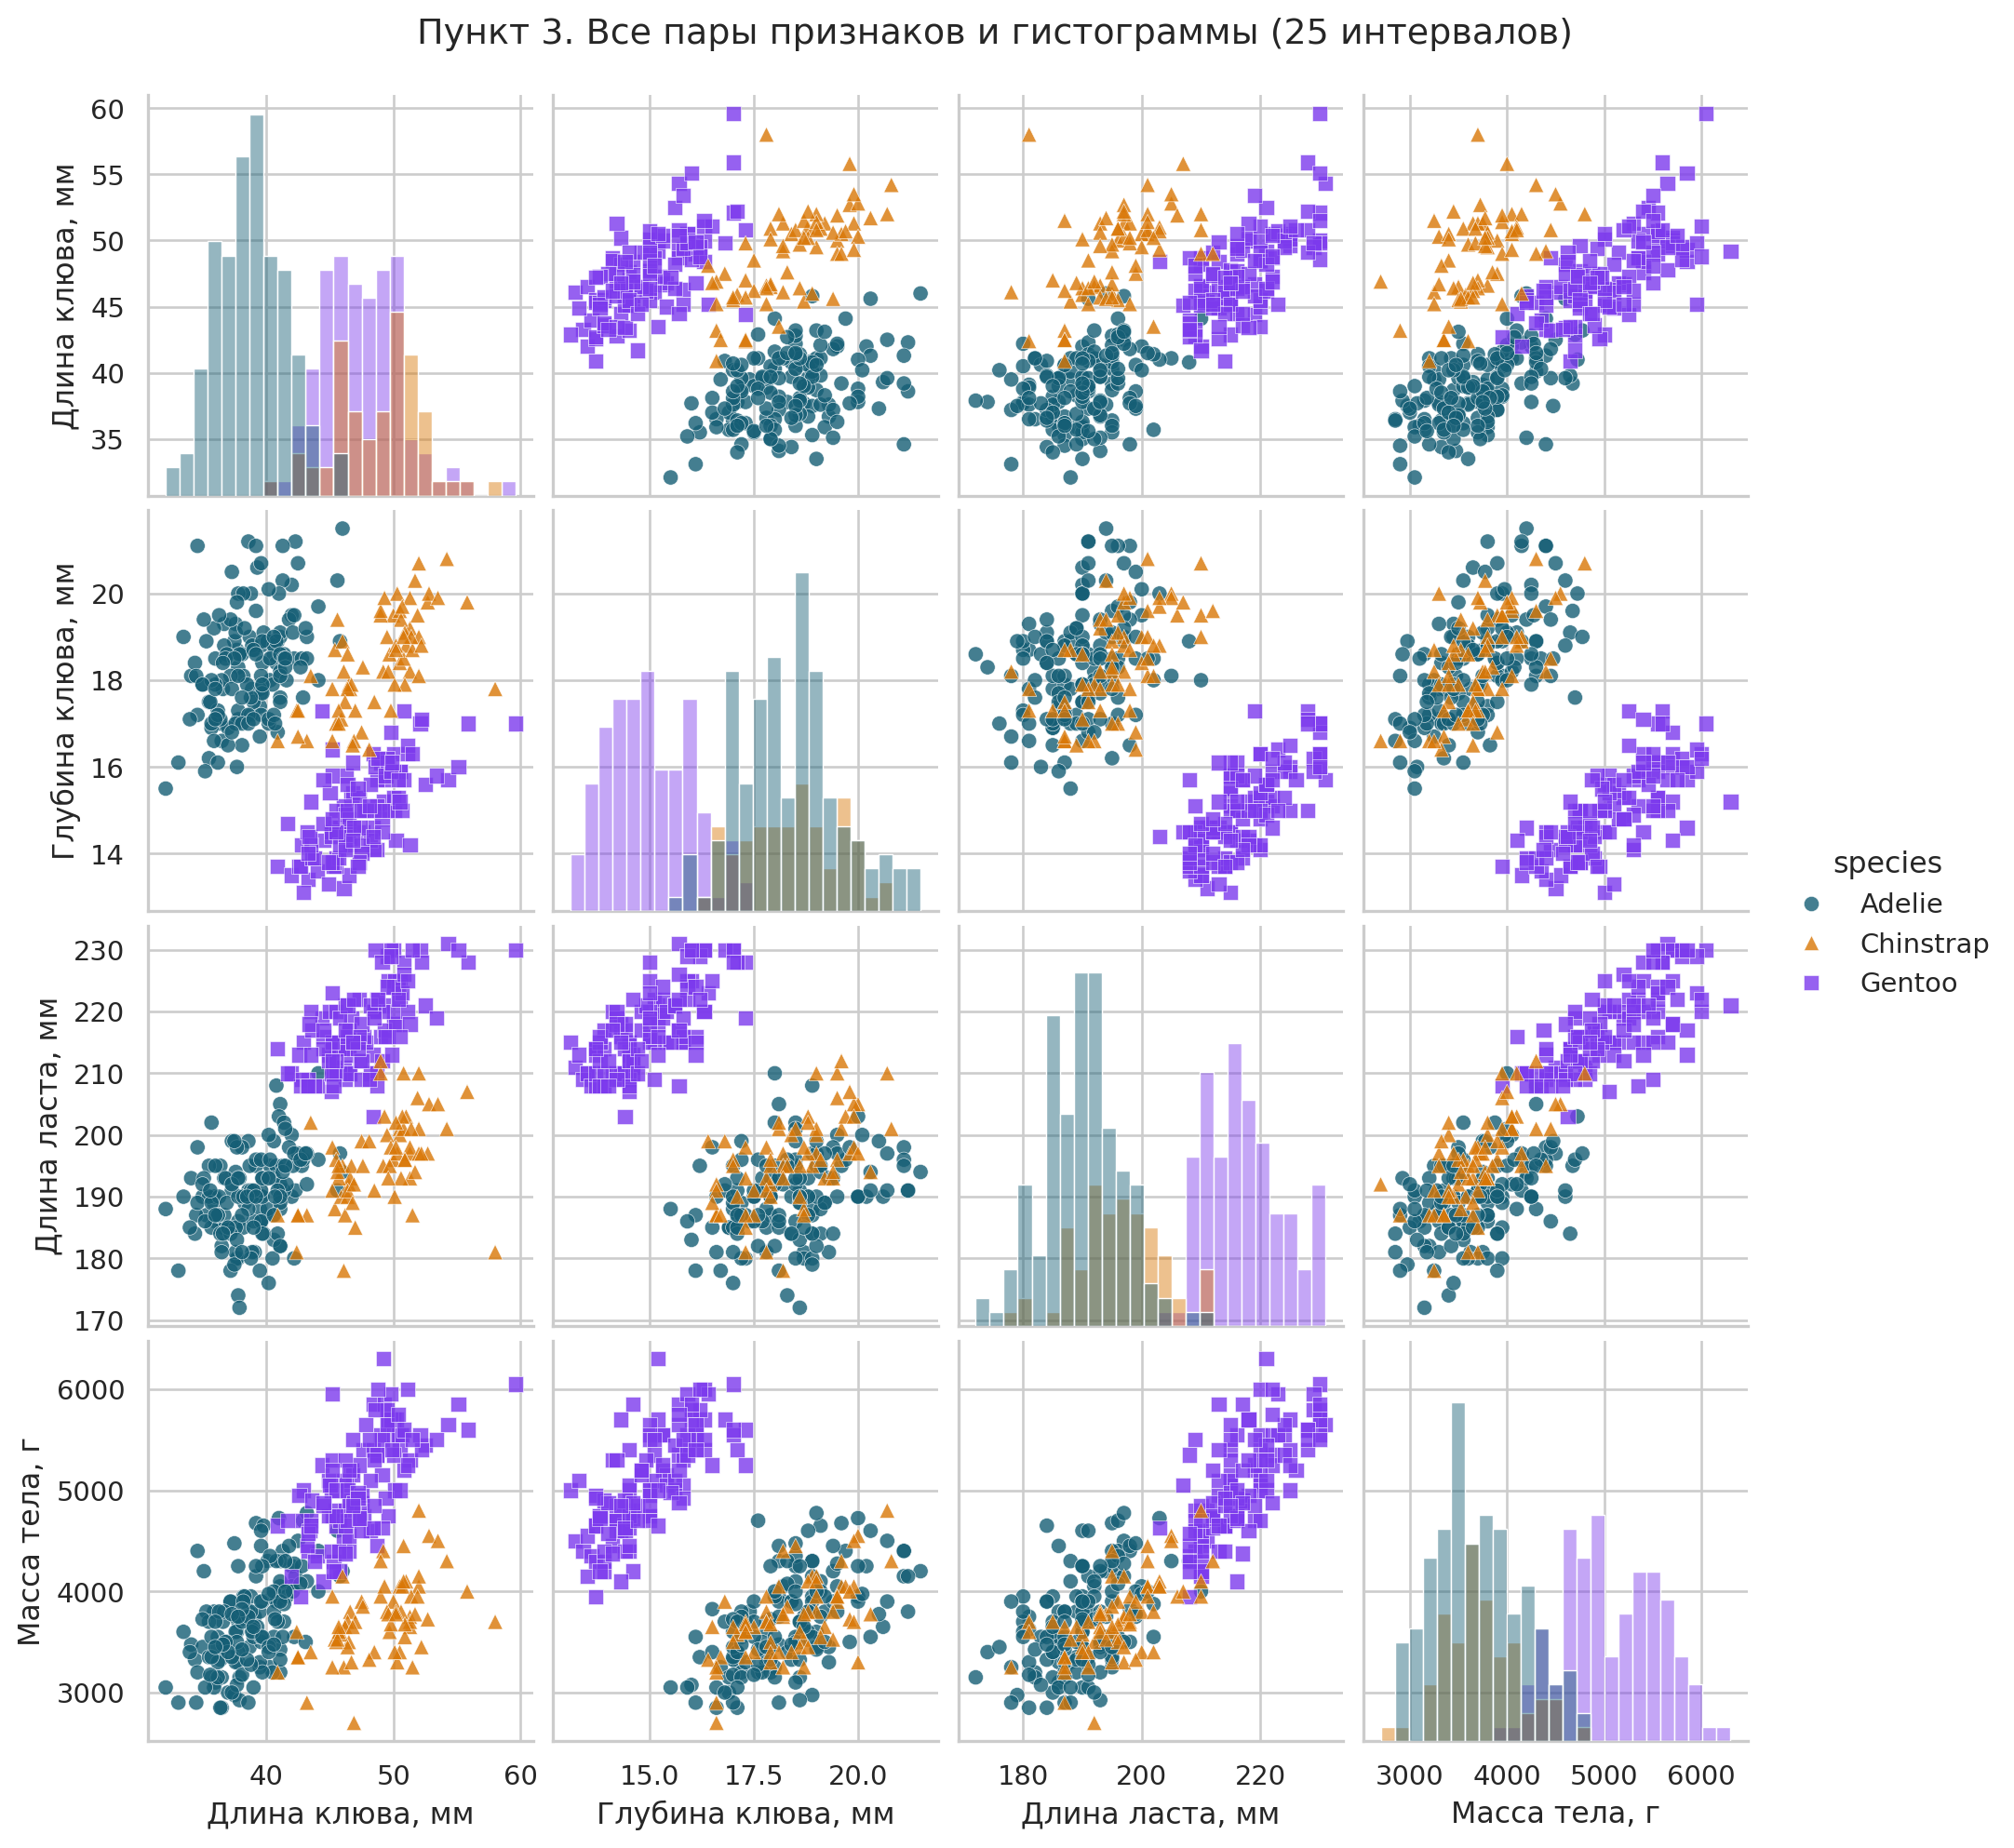

In [5]:
# [3] Every ordered feature pair and a histogram on each diagonal.
grid = sns.pairplot(
    filtered,
    vars=FEATURES,
    hue="species",
    hue_order=CLASS_ORDER,
    palette=COLORS,
    # pairplot associates markers with first appearance in the source table.
    markers=[MARKERS[c] for c in filtered["species"].drop_duplicates()],
    diag_kind="hist",
    diag_kws={"bins": 25, "alpha": 0.45},
    plot_kws={"alpha": 0.8, "s": 38, "edgecolor": "white", "linewidth": 0.25},
    height=2.55,
)
for row in grid.axes:
    for ax in row:
        if ax is not None:
            ax.set_xlabel(FEATURE_LABELS.get(ax.get_xlabel(), ax.get_xlabel()))
            ax.set_ylabel(FEATURE_LABELS.get(ax.get_ylabel(), ax.get_ylabel()))
grid.fig.suptitle("Пункт 3. Все пары признаков и гистограммы (25 интервалов)", y=1.025)
save_plot(grid.fig, "03_pairplot.png")

display(Image(filename=str(FIGURES / '03_pairplot.png')))


## [4] Корреляции Пирсона

Сначала вычисляем корреляции по всей отфильтрованной выборке, затем отдельно в каждом виде. Коэффициент описывает линейную связь, но не доказывает причинность. Обратите внимание: связь глубины клюва и массы тела отрицательна в общей выборке, но положительна внутри каждого вида.

In [6]:
# [4] Pearson correlation on the same complete observations overall and by class.
correlations: dict[str, pd.DataFrame] = {"all": filtered[FEATURES].corr(method="pearson")}
for species in CLASS_ORDER:
    correlations[species] = filtered.loc[filtered.species == species, FEATURES].corr(method="pearson")
for name, corr in correlations.items():
    save_table(corr, f"04_pearson_{name.lower()}.csv", index=True)

for name, matrix in correlations.items():
    display(Markdown(f'### {name}'), matrix.round(3))


### all

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


### Adelie

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.391,0.326,0.549
bill_depth_mm,0.391,1.000,0.308,0.576
flipper_length_mm,0.326,0.308,1.000,0.468
body_mass_g,0.549,0.576,0.468,1.000


### Chinstrap

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.654,0.472,0.514
bill_depth_mm,0.654,1.000,0.580,0.604
flipper_length_mm,0.472,0.580,1.000,0.642
body_mass_g,0.514,0.604,0.642,1.000


### Gentoo

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.643,0.661,0.669
bill_depth_mm,0.643,1.000,0.707,0.719
flipper_length_mm,0.661,0.707,1.000,0.703
body_mass_g,0.669,0.719,0.703,1.000


## [5] LDA: решающие функции и области

Выбираем `Adelie` и `Chinstrap`, положительный класс — `Chinstrap`. Делим объекты на обучение и контроль с сохранением пропорций классов. Обучаем одну LDA на всех четырёх измерениях и ещё шесть LDA — по одной для каждой пары, чтобы честно показать двухмерные решающие области. Решающая функция имеет вид `f(x) = b + Σ(wᵢ·xᵢ)`; если `f(x) > 0`, выбирается Chinstrap.

In [7]:
# One fixed stratified split for the binary work in items [5]–[8].
binary = filtered.loc[filtered.species.isin(BINARY_CLASSES)].reset_index(drop=True)
labels = (binary.species == POSITIVE_CLASS).astype(int)
train_ids, test_ids = train_test_split(
    np.arange(len(binary)), test_size=0.25, stratify=labels, random_state=RANDOM_STATE
)
binary_train = binary.iloc[train_ids]
binary_test = binary.iloc[test_ids]
y_train = labels.iloc[train_ids]
y_test = labels.iloc[test_ids]
split_table = pd.DataFrame(
    {
        "Класс": BINARY_CLASSES,
        "Обучение": [int((binary_train.species == c).sum()) for c in BINARY_CLASSES],
        "Контроль": [int((binary_test.species == c).sum()) for c in BINARY_CLASSES],
    }
)
save_table(split_table, "05_08_split.csv")

display(Markdown('### Обучение и контроль'), split_table)


### Обучение и контроль

,Класс,Обучение,Контроль
0,Adelie,113,38
1,Chinstrap,51,17


### Коэффициенты в исходных единицах

,Модель,intercept,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Accuracy на контроле
0,Все 4 признака,-61.368758,1.583116,-0.754051,0.121591,-0.005004,1.000000
1,bill_length_mm + bill_depth_mm,-36.714881,1.405617,-1.406797,NaN,NaN,1.000000
2,bill_length_mm + flipper_length_mm,-45.299700,1.183534,NaN,-0.039348,NaN,0.981818
3,bill_length_mm + body_mass_g,-49.973602,1.556164,NaN,NaN,-0.005168,0.981818
4,bill_depth_mm + flipper_length_mm,-26.693991,NaN,-0.183609,0.151442,NaN,0.727273
5,bill_depth_mm + body_mass_g,-3.656436,NaN,0.170907,NaN,-0.000079,0.690909
6,flipper_length_mm + body_mass_g,-31.021226,NaN,NaN,0.179696,-0.001210,0.654545


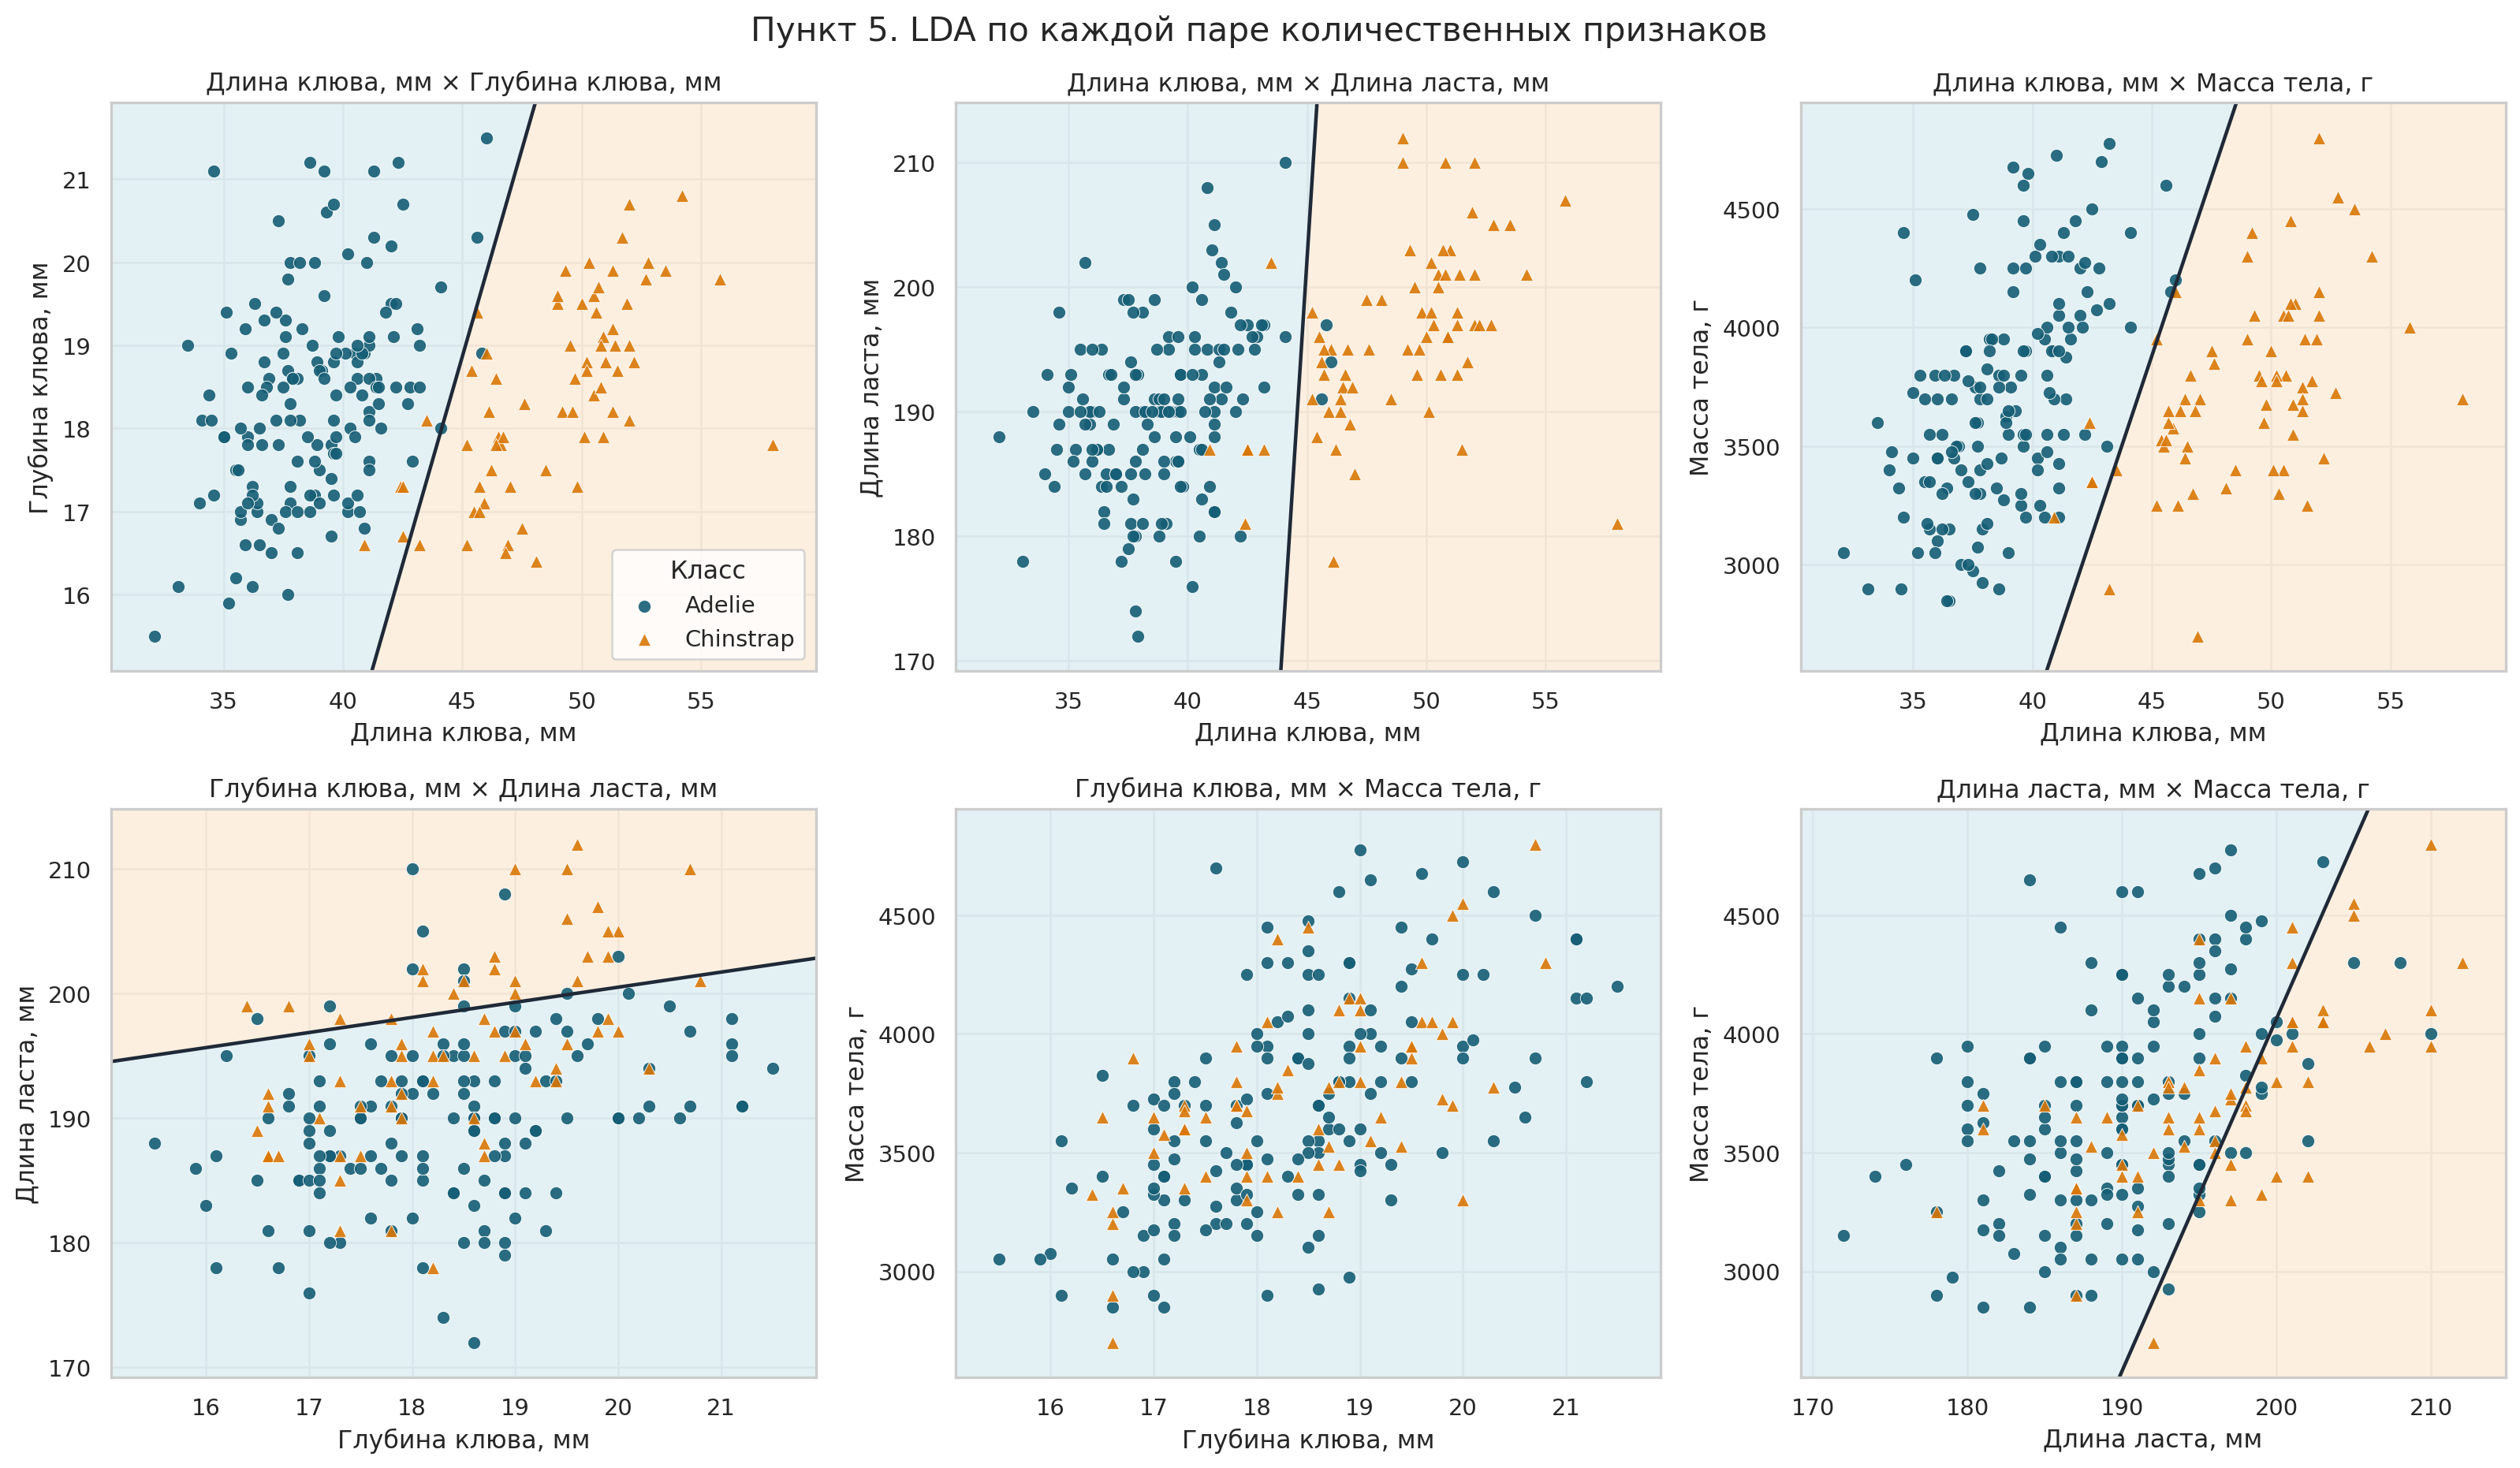

In [8]:
# [5] Full four-feature LDA plus six separate two-feature LDA maps.
full_lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
full_lda.fit(binary_train[FEATURES], y_train)
full_accuracy = accuracy_score(y_test, full_lda.predict(binary_test[FEATURES]))
coefficient_rows = [
    {
        "Модель": "Все 4 признака",
        **raw_lda_coefficients(full_lda, FEATURES),
        "Accuracy на контроле": full_accuracy,
    }
]
pair_models = {}
pairs = list(combinations(FEATURES, 2))
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (x, y) in zip(axes.flat, pairs):
    model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
    model.fit(binary_train[[x, y]], y_train)
    pair_models[(x, y)] = model
    coefficient_rows.append(
        {
            "Модель": f"{x} + {y}",
            **raw_lda_coefficients(model, [x, y]),
            "Accuracy на контроле": accuracy_score(y_test, model.predict(binary_test[[x, y]])),
        }
    )
    draw_regions(ax, model, binary, x, y, f"{FEATURE_LABELS[x]} × {FEATURE_LABELS[y]}")
axes[0, 0].legend(title="Класс", loc="best")
fig.suptitle("Пункт 5. LDA по каждой паре количественных признаков", fontsize=16)
fig.tight_layout()
save_plot(fig, "05_lda_all_pairs.png")
coefficient_table = pd.DataFrame(coefficient_rows)
save_table(coefficient_table, "05_lda_coefficients.csv")

display(Markdown('### Коэффициенты в исходных единицах'), coefficient_table.round(6))
display(Image(filename=str(FIGURES / '05_lda_all_pairs.png')))


## [6] LDA и линейная регрессия

На одном графике сравниваем границу классификации LDA с прямой регрессии глубины клюва по его длине. Регрессия предсказывает число, LDA — вид пингвина.

,Зависимая переменная,Независимая переменная,Свободный член,Наклон,R² на обучении
0,bill_depth_mm,bill_length_mm,15.632,0.066,0.095


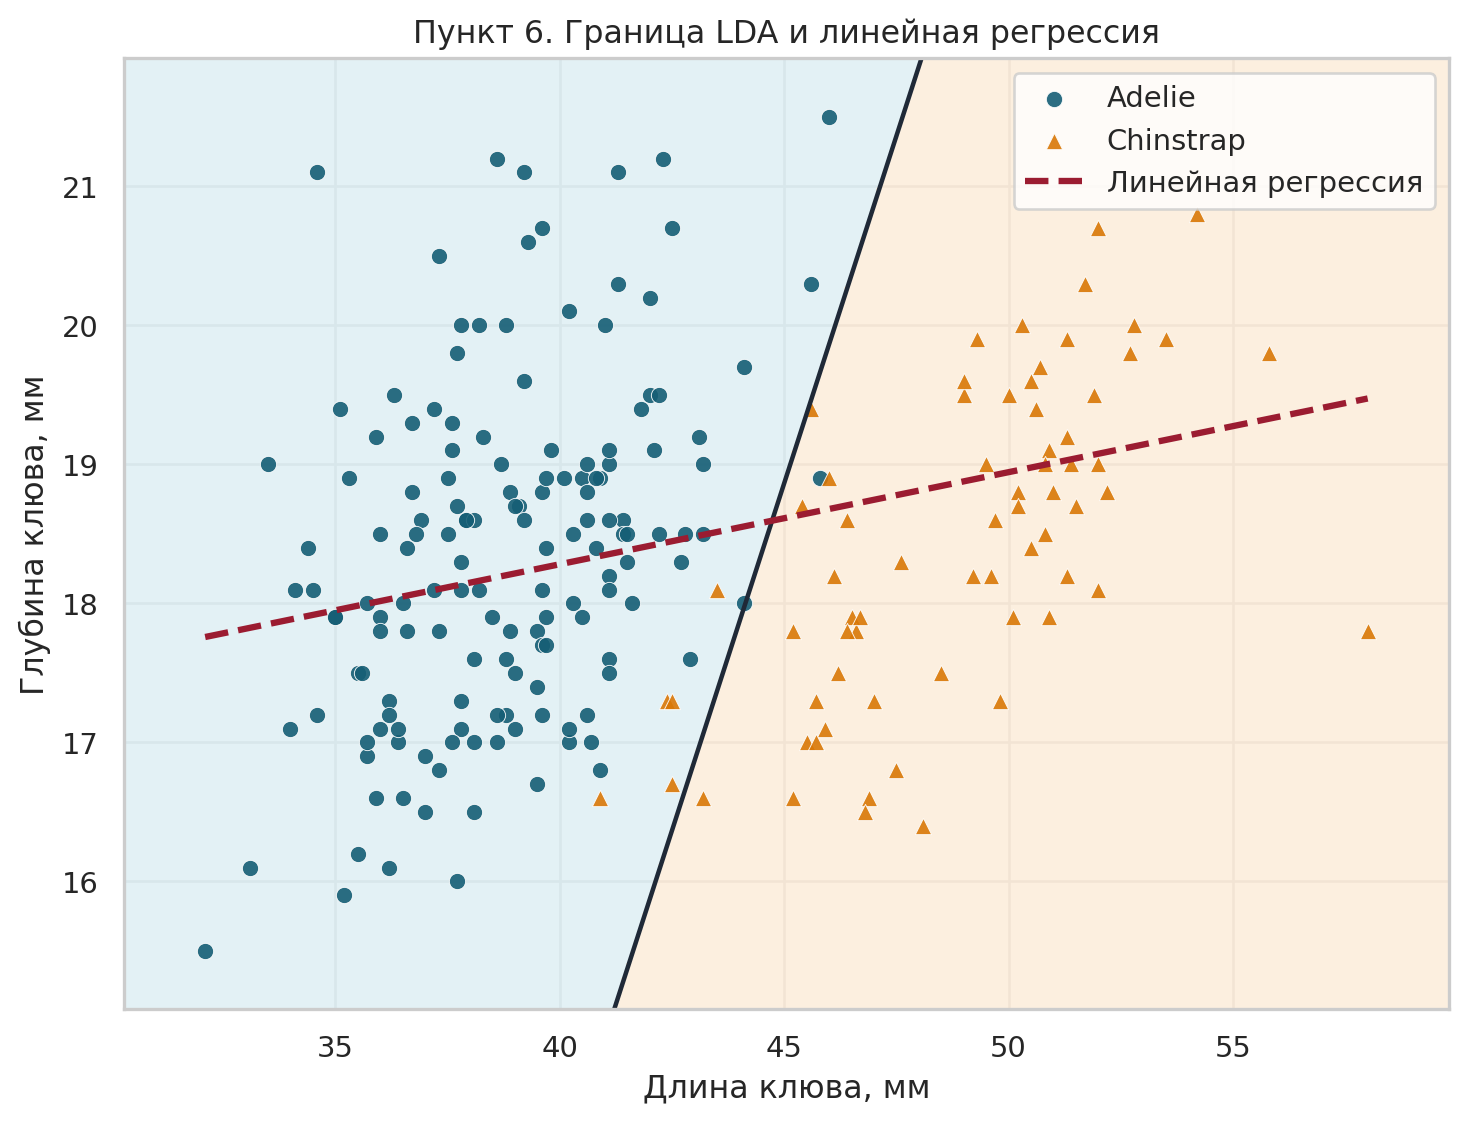

In [9]:
# [6] The same two-feature LDA boundary and an ordinary least-squares line.
regression_pair = ("bill_length_mm", "bill_depth_mm")
x, y = regression_pair
regression = LinearRegression().fit(binary_train[[x]], binary_train[y])
fig, ax = plt.subplots(figsize=(9, 6.5))
draw_regions(ax, pair_models[regression_pair], binary, x, y, "Пункт 6. Граница LDA и линейная регрессия")
x_line = np.linspace(binary[x].min(), binary[x].max(), 200)
y_line = regression.predict(pd.DataFrame({x: x_line}))
ax.plot(x_line, y_line, color="#9b1c31", linestyle="--", linewidth=2.4, label="Линейная регрессия")
ax.legend(loc="best")
save_plot(fig, "06_lda_and_regression.png")
regression_info = pd.DataFrame(
    {
        "Зависимая переменная": [y],
        "Независимая переменная": [x],
        "Свободный член": [regression.intercept_],
        "Наклон": [regression.coef_[0]],
        "R² на обучении": [regression.score(binary_train[[x]], binary_train[y])],
    }
)
save_table(regression_info, "06_regression.csv")

display(regression_info.round(3))
display(Image(filename=str(FIGURES / '06_lda_and_regression.png')))


## [7] Сравнение четырёх классификаторов

Берём глубину клюва и длину ласта. Обучение и контроль у всех методов одинаковые. LDA, линейный SVM и логистическая регрессия дают прямые границы; у гауссовского наивного Байеса граница может быть изогнутой.

### LDA

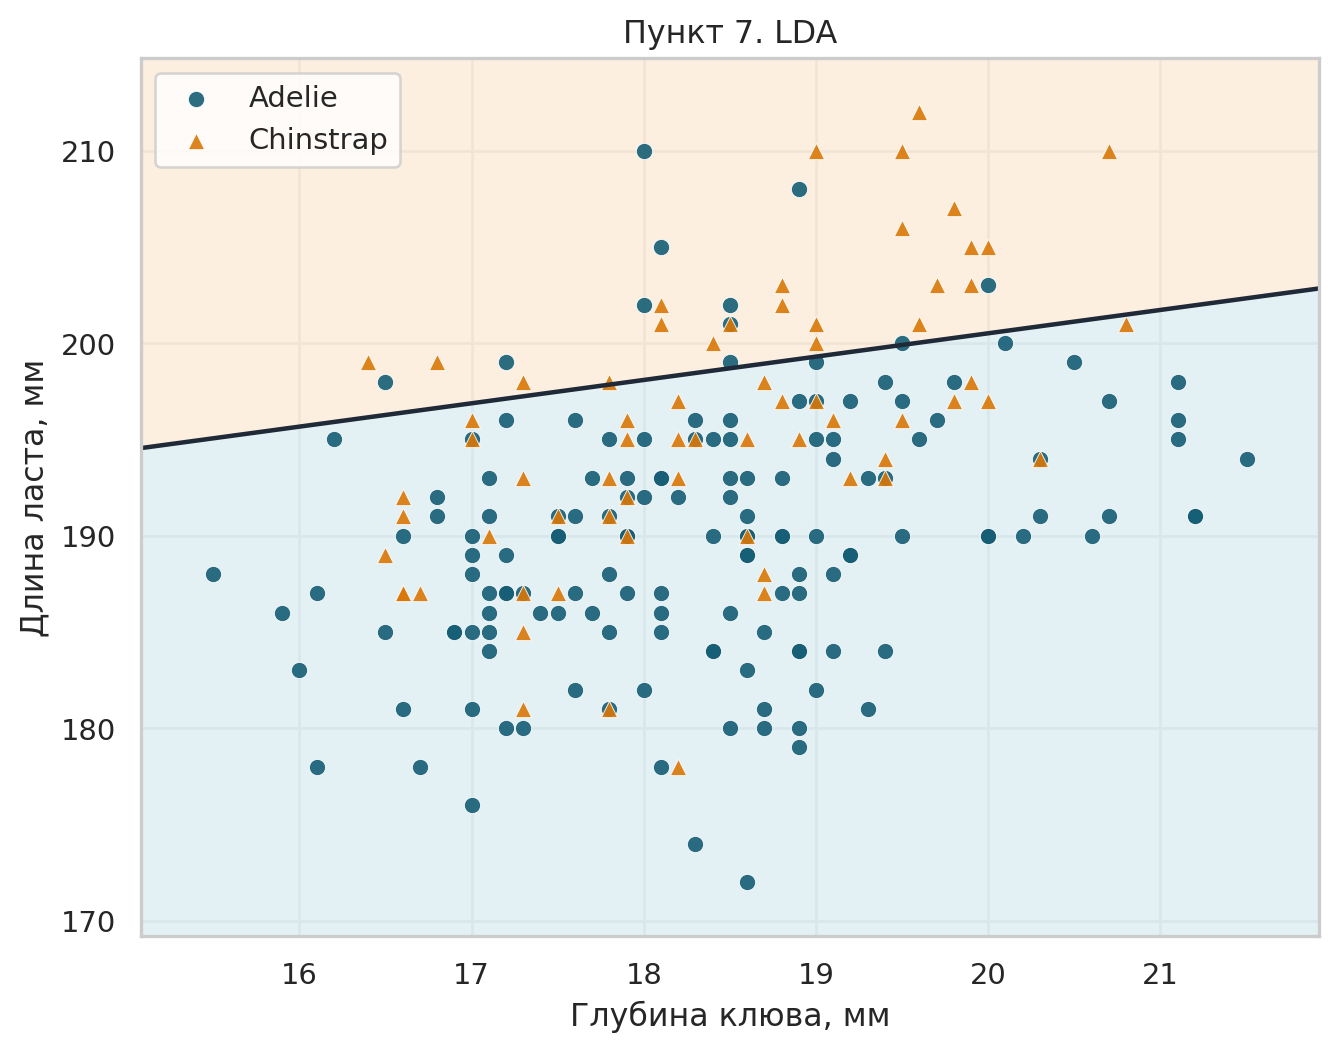

### SVM (линейный)

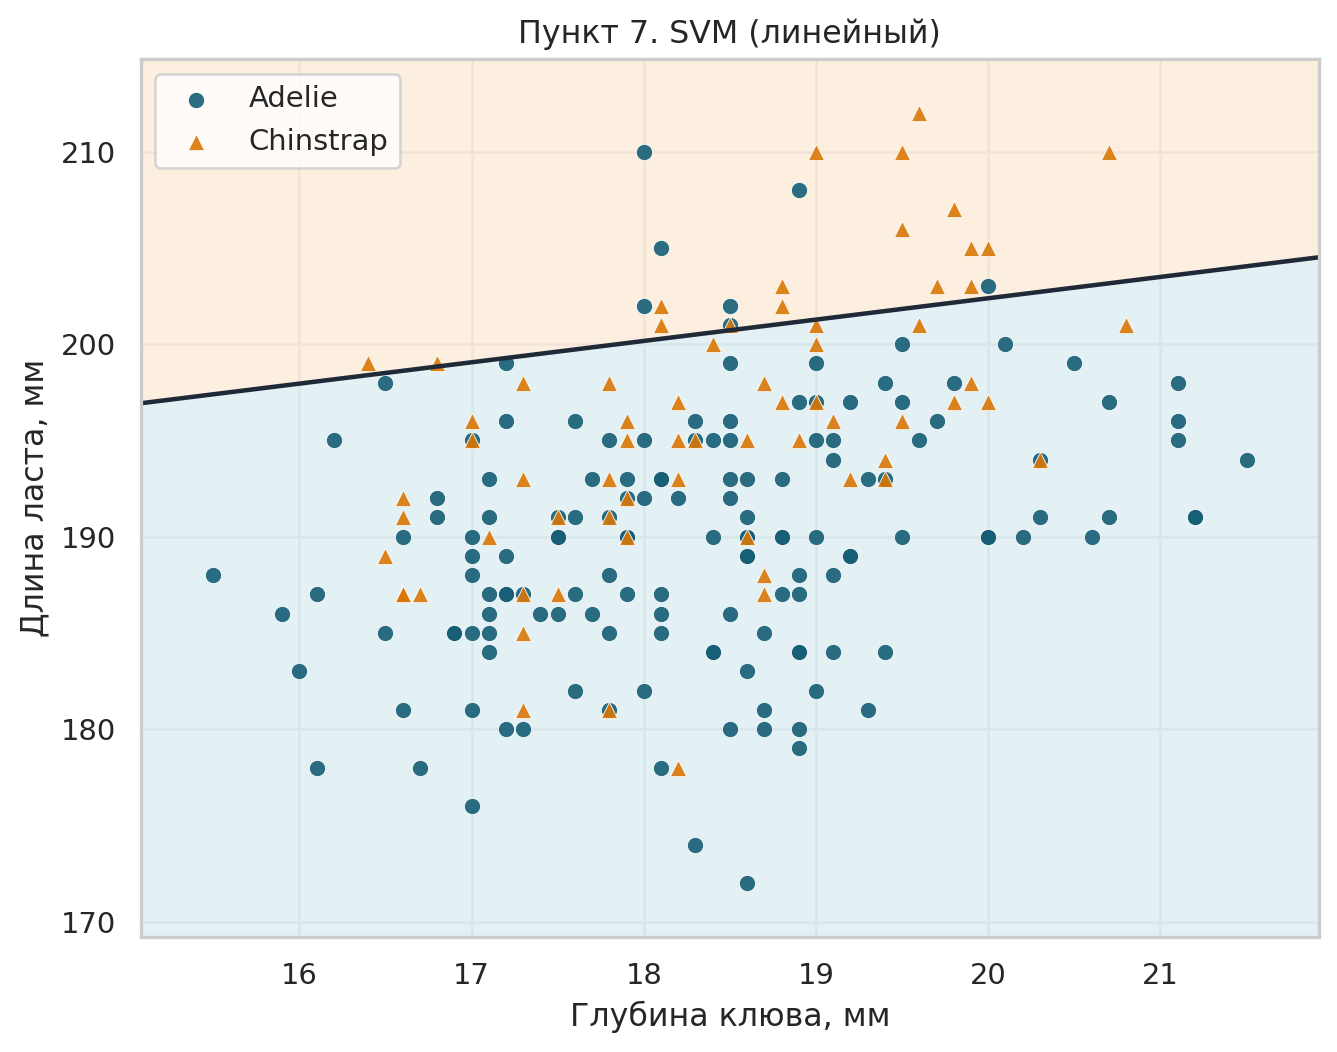

### Логистическая регрессия

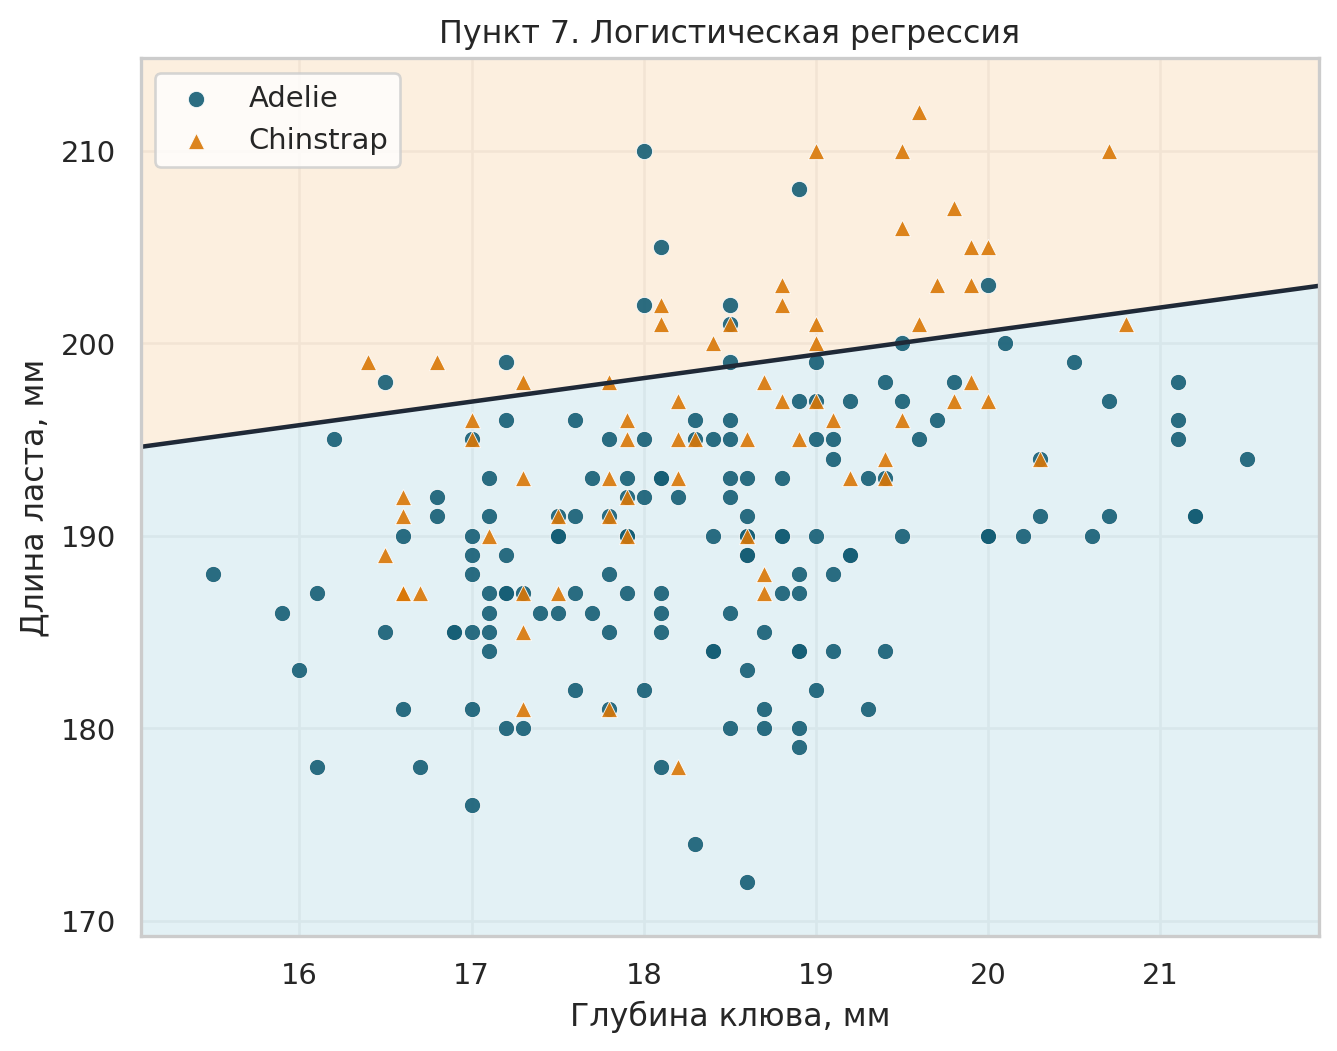

### Наивный Байес

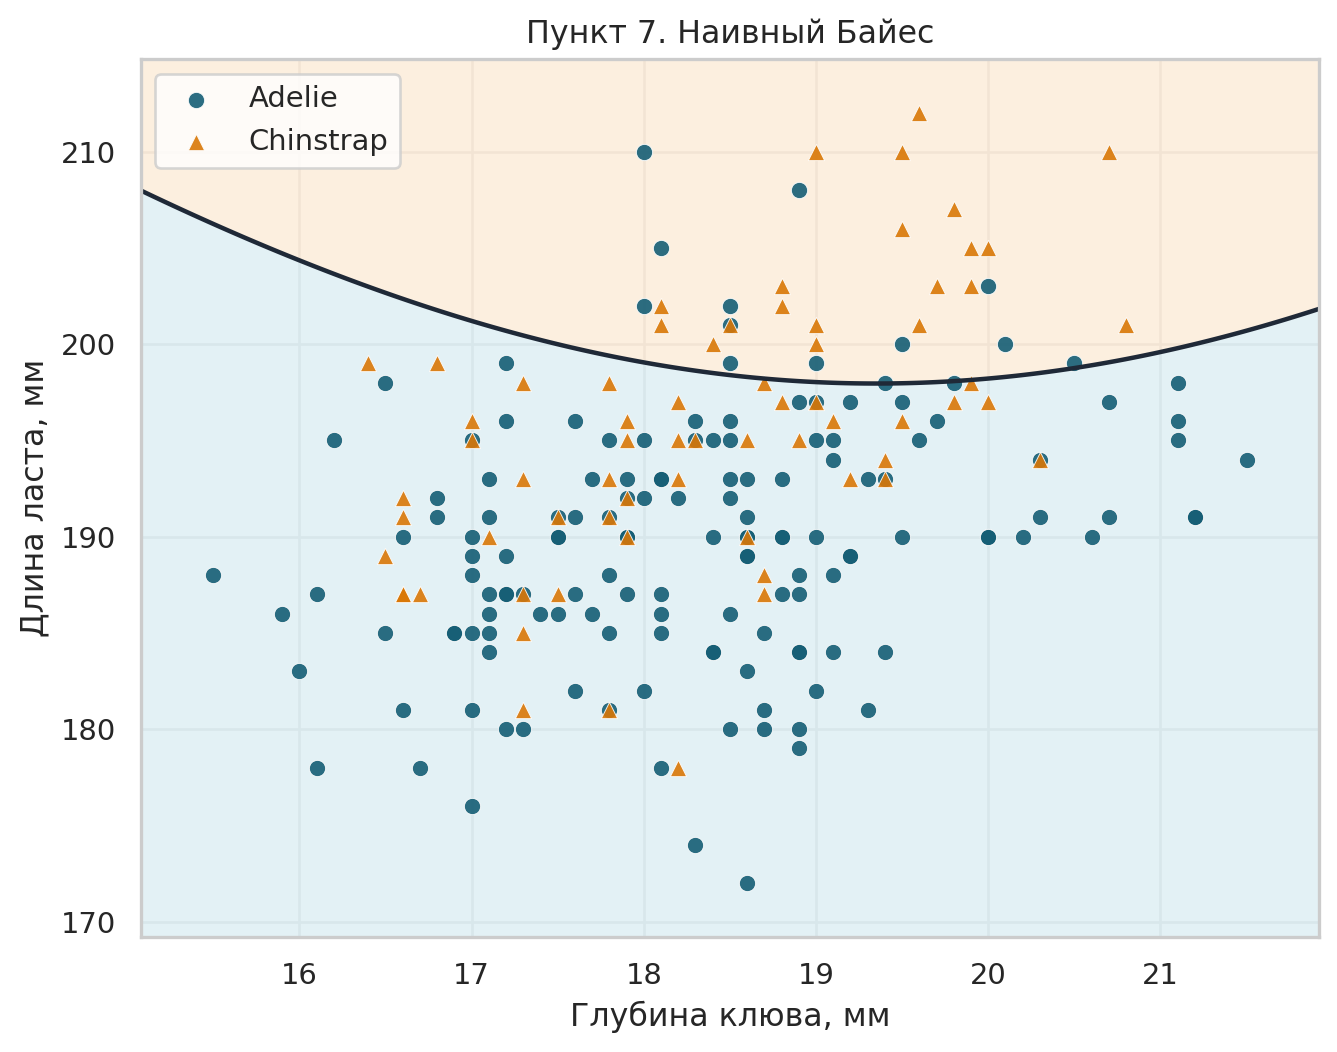

In [10]:
# [7] A more overlapping pair makes the differences between methods visible.
comparison_pair = ("bill_depth_mm", "flipper_length_mm")
x_comparison, y_comparison = comparison_pair
models = {
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "SVM (линейный)": make_pipeline(StandardScaler(), SVC(kernel="linear")),
    "Логистическая регрессия": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Наивный Байес": make_pipeline(StandardScaler(), GaussianNB()),
}
file_stems = {
    "LDA": "lda",
    "SVM (линейный)": "svm_linear",
    "Логистическая регрессия": "logistic_regression",
    "Наивный Байес": "gaussian_naive_bayes",
}
for name, model in models.items():
    model.fit(binary_train[list(comparison_pair)], y_train)
    fig, ax = plt.subplots(figsize=(8, 6))
    draw_regions(ax, model, binary, x_comparison, y_comparison, f"Пункт 7. {name}")
    ax.legend(loc="best")
    save_plot(fig, f"07_{file_stems[name]}.png")

for method, stem in file_stems.items():
    display(Markdown(f'### {method}'))
    display(Image(filename=str(FIGURES / f'07_{stem}.png')))


## [8] Ошибки, метрики и ROC

Положительный класс — Chinstrap. Строки матрицы ошибок — истинные классы, столбцы — прогнозы. `sensitivity = recall = TP/(TP+FN)`, `specificity = TN/(TN+FP)`, `precision = TP/(TP+FP)`. ROC показывает TPR против FPR при изменении порога; AUC — площадь под ROC. Все значения считаются на отложенной контрольной выборке.

,Метод,TN,FP,FN,TP,Sensitivity,Specificity,Precision,Recall,AUC,Accuracy
0,LDA,35,3,12,5,0.294,0.921,0.625,0.294,0.737,0.727
1,SVM (линейный),36,2,14,3,0.176,0.947,0.600,0.176,0.726,0.709
2,Логистическая регрессия,36,2,12,5,0.294,0.947,0.714,0.294,0.737,0.745
3,Наивный Байес,34,4,14,3,0.176,0.895,0.429,0.176,0.652,0.673


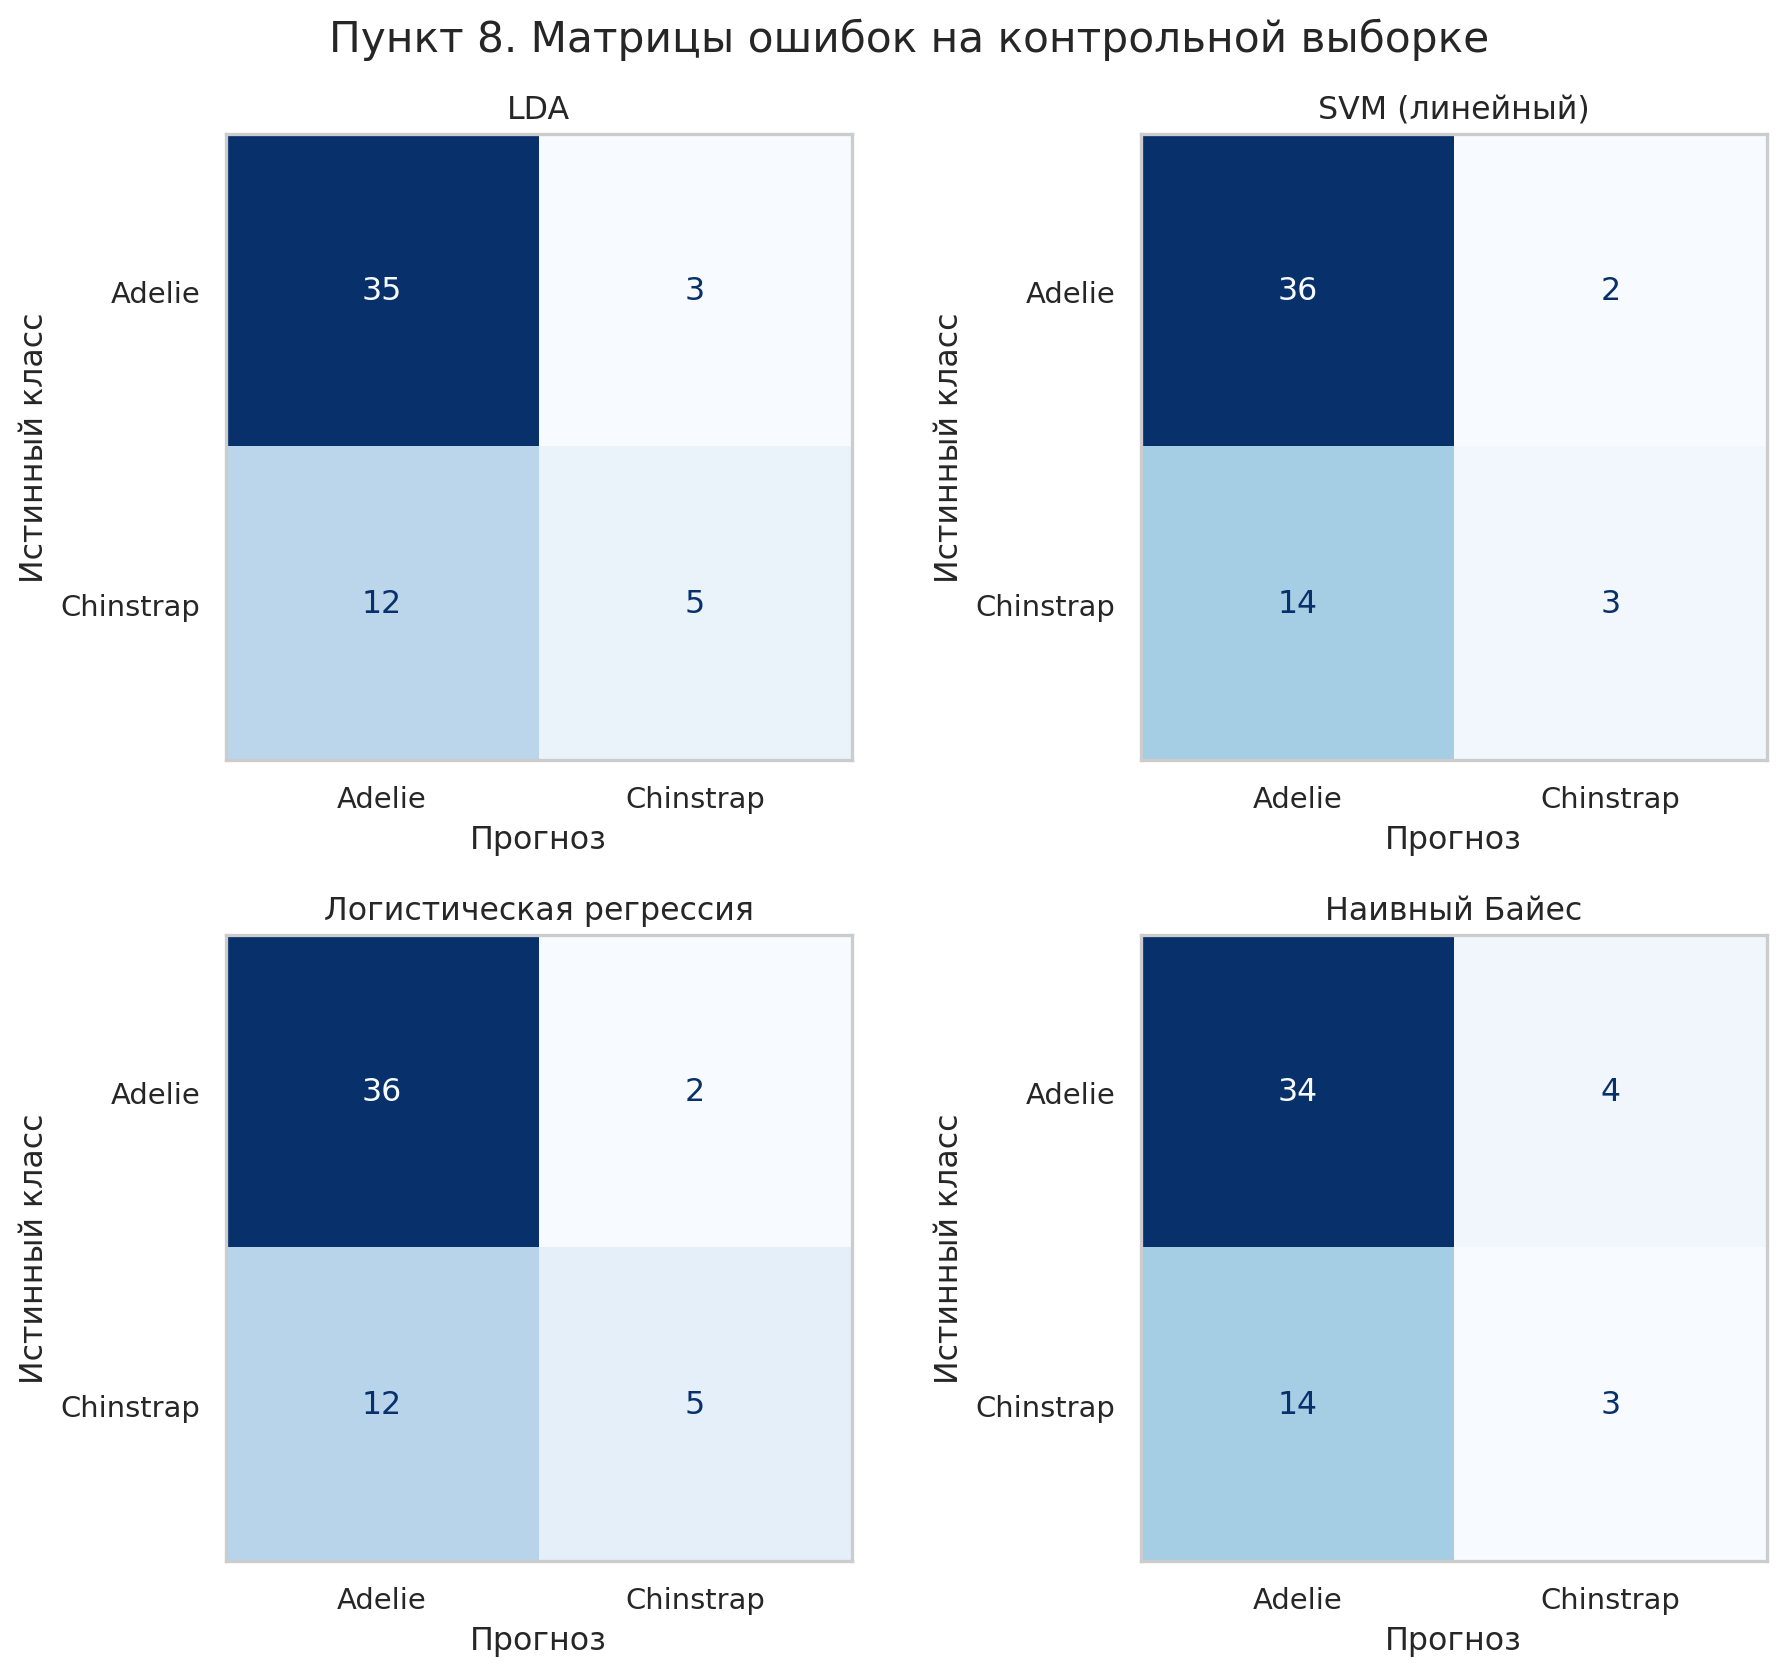

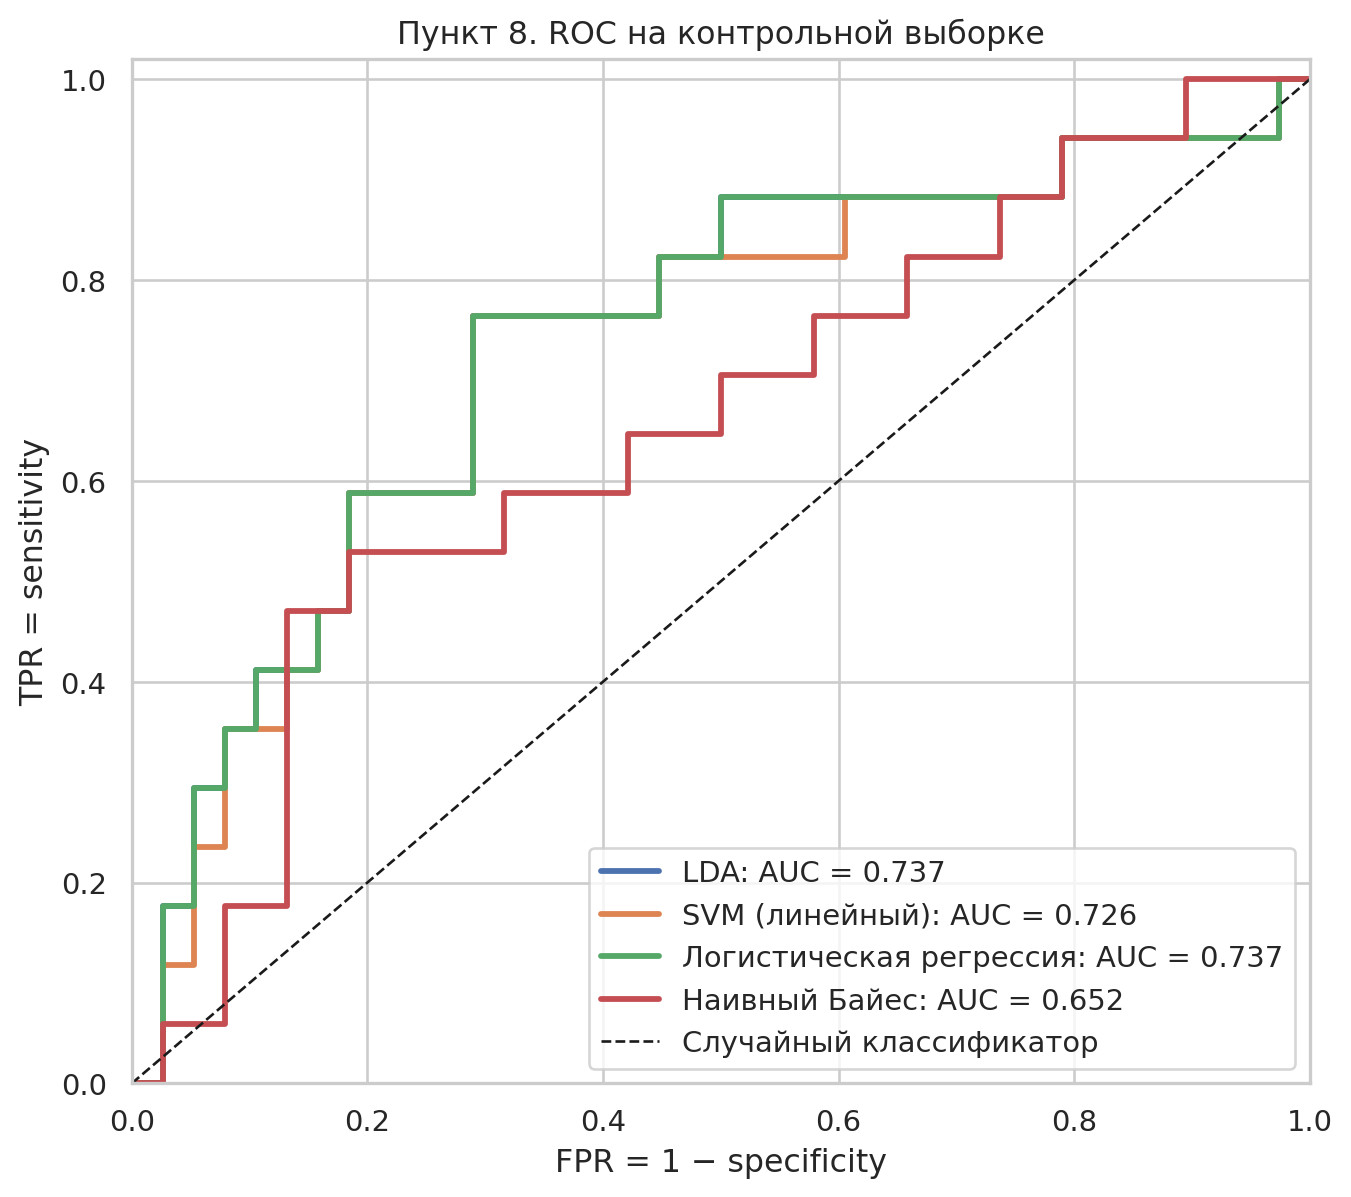

In [11]:
# [8] Classification metrics, confusion matrices, and ROC on held-out data.
metric_rows = []
confusion_rows = []
roc_rows = []
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8, 7))
for ax, (name, model) in zip(axes_cm.flat, models.items()):
    y_pred = model.predict(binary_test[list(comparison_pair)])
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    score = model_score(model, binary_test[list(comparison_pair)])
    fpr, tpr, thresholds = roc_curve(y_test, score)
    area = auc(fpr, tpr)
    metric_rows.append(
        {
            "Метод": name,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "Recall": sensitivity,
            "AUC": area,
            "Accuracy": accuracy_score(y_test, y_pred),
        }
    )
    for true_label, predicted_label, count in [
        ("Adelie", "Adelie", tn),
        ("Adelie", "Chinstrap", fp),
        ("Chinstrap", "Adelie", fn),
        ("Chinstrap", "Chinstrap", tp),
    ]:
        confusion_rows.append(
            {"Метод": name, "Истинный класс": true_label, "Прогноз": predicted_label, "Количество": count}
        )
    for a, b, threshold in zip(fpr, tpr, thresholds):
        roc_rows.append({"Метод": name, "FPR": a, "TPR": b, "Порог": threshold})
    ConfusionMatrixDisplay(
        confusion_matrix=np.array([[tn, fp], [fn, tp]]),
        display_labels=BINARY_CLASSES,
    ).plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name)
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Истинный класс")
    ax.grid(False)
    ax_roc.plot(fpr, tpr, linewidth=2.2, label=f"{name}: AUC = {area:.3f}")
ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1, label="Случайный классификатор")
ax_roc.set_xlabel("FPR = 1 − specificity")
ax_roc.set_ylabel("TPR = sensitivity")
ax_roc.set_title("Пункт 8. ROC на контрольной выборке")
ax_roc.legend(loc="lower right")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
fig_cm.suptitle("Пункт 8. Матрицы ошибок на контрольной выборке", fontsize=16)
fig_cm.tight_layout()
save_plot(fig_cm, "08_confusion_matrices.png")
save_plot(fig_roc, "08_roc.png")
metrics = pd.DataFrame(metric_rows)
save_table(metrics, "08_metrics.csv")
save_table(pd.DataFrame(confusion_rows), "08_confusion_matrices.csv")
save_table(pd.DataFrame(roc_rows), "08_roc_points.csv")

display(metrics.round(3))
display(Image(filename=str(FIGURES / '08_confusion_matrices.png')))
display(Image(filename=str(FIGURES / '08_roc.png')))


## Вывод

По выбранным для сравнения двум признакам классы заметно перекрываются, поэтому даже метод с наибольшей accuracy пропускает часть Chinstrap. Значения метрик зависят от фиксированного разбиения и не служат гарантией качества на новых наблюдениях. Полный письменный разбор сохранён в [REPORT.md](https://github.com/DEMest/MachineLearning/blob/main/REPORT.md).